In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [78]:
df = pd.read_csv("PlayGolf-MissingData.csv")

In [79]:
df.head(20)

,Unnamed: 0,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,0,08-01,0,0.0,25.1,99.0,0.0,rainy,0.14
1,1,08-02,1,0.0,26.4,NaN,0.0,sunny,NaN
2,2,08-03,2,0.0,NaN,96.0,0.0,rainy,0.21
3,3,08-04,3,0.0,24.1,68.0,0.0,overcast,0.68
4,4,08-05,4,NaN,24.7,98.0,0.0,rainy,0.20
5,5,08-06,5,0.0,26.5,98.0,0.0,NaN,0.32
6,6,08-07,6,0.0,27.6,78.0,0.0,rainy,0.72
7,7,08-08,0,0.0,28.2,NaN,0.0,rainy,0.61
8,8,08-09,1,0.0,27.1,70.0,0.0,overcast,NaN
9,9,08-10,2,1.0,26.7,75.0,NaN,sunny,0.54


In [80]:
df.shape

(20, 9)

In [81]:
df.columns

Index(['Unnamed: 0', 'Date', 'Weekday', 'Holiday', 'Temp', 'Humidity', 'Wind',
       'Outlook', 'Crowdedness'],
      dtype='object')

In [82]:
df.describe()

,Unnamed: 0,Weekday,Holiday,Temp,Humidity,Wind,Crowdedness
count,20.00000,20.000000,18.000000,16.000000,16.000000,18.000000,15.000000
mean,9.50000,2.850000,0.055556,25.950000,82.187500,0.277778,0.502667
std,5.91608,1.980829,0.235702,1.801111,10.765493,0.460889,0.209061
min,0.00000,0.000000,0.000000,22.400000,68.000000,0.000000,0.140000
25%,4.75000,1.000000,0.000000,24.600000,74.500000,0.000000,0.350000
50%,9.50000,3.000000,0.000000,26.500000,77.500000,0.000000,0.540000
75%,14.25000,4.250000,0.000000,27.025000,90.750000,0.750000,0.665000
max,19.00000,6.000000,1.000000,28.600000,99.000000,1.000000,0.810000


In [83]:
df = df.drop(columns="Unnamed: 0")

In [84]:
df.isnull().sum()

,0
Date,0
Weekday,0
Holiday,2
Temp,4
Humidity,4
Wind,2
Outlook,3
Crowdedness,5


<Axes: xlabel='Temp', ylabel='Count'>

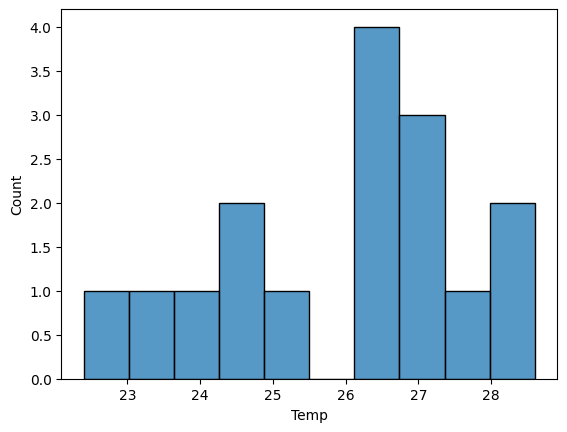

In [85]:
sns.histplot(df["Temp"], bins=10)

<Axes: xlabel='Crowdedness', ylabel='Count'>

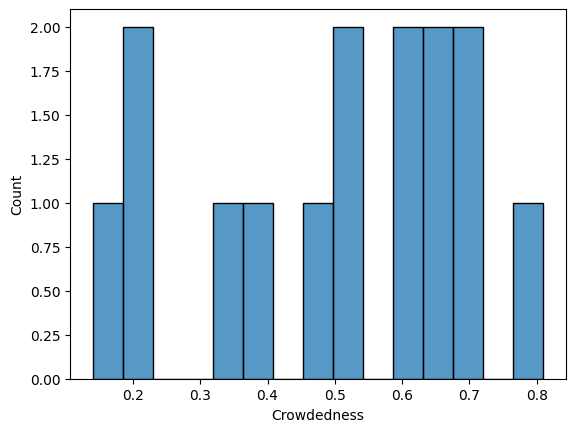

In [86]:
sns.histplot(df["Crowdedness"], bins=15)

In [87]:
df_clean = df[df.isnull().sum(axis=1) < 4].reset_index(drop=True).copy()

In [88]:
df_clean.head()

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,0.0,25.1,99.0,0.0,rainy,0.14
1,08-02,1,0.0,26.4,NaN,0.0,sunny,NaN
2,08-03,2,0.0,NaN,96.0,0.0,rainy,0.21
3,08-04,3,0.0,24.1,68.0,0.0,overcast,0.68
4,08-05,4,NaN,24.7,98.0,0.0,rainy,0.20


In [101]:
df_clean["Humidity"] = df_clean["Humidity"].fillna(df_clean["Humidity"].mean())
df_clean["Holiday"] = df_clean["Humidity"].fillna(df_clean["Holiday"].mode()[0])

In [102]:
df_clean.head()

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,99.0000,25.10,99.0000,0.0,rainy,0.14
1,08-02,1,82.1875,26.40,82.1875,0.0,sunny,NaN
2,08-03,2,96.0000,25.25,96.0000,0.0,rainy,0.21
3,08-04,3,68.0000,24.10,68.0000,0.0,overcast,0.68
4,08-05,4,98.0000,24.70,98.0000,0.0,rainy,0.20


In [103]:
df_clean["Temp"] = df_clean["Temp"].interpolate(method="linear")
df_clean.head()

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,99.0000,25.10,99.0000,0.0,rainy,0.14
1,08-02,1,82.1875,26.40,82.1875,0.0,sunny,NaN
2,08-03,2,96.0000,25.25,96.0000,0.0,rainy,0.21
3,08-04,3,68.0000,24.10,68.0000,0.0,overcast,0.68
4,08-05,4,98.0000,24.70,98.0000,0.0,rainy,0.20


In [104]:
df_clean["Outlook"] = df_clean["Outlook"].ffill()
df_clean.head()

,Date,Weekday,Holiday,Temp,Humidity,Wind,Outlook,Crowdedness
0,08-01,0,99.0000,25.10,99.0000,0.0,rainy,0.14
1,08-02,1,82.1875,26.40,82.1875,0.0,sunny,NaN
2,08-03,2,96.0000,25.25,96.0000,0.0,rainy,0.21
3,08-04,3,68.0000,24.10,68.0000,0.0,overcast,0.68
4,08-05,4,98.0000,24.70,98.0000,0.0,rainy,0.20


In [105]:
df_clean.isnull().sum()

,0
Date,0
Weekday,0
Holiday,0
Temp,0
Humidity,0
Wind,1
Outlook,0
Crowdedness,3
